## 逻辑回归

### 1.基础环境配置

In [1]:
import numpy
import matplotlib.pyplot
import matplotlib.patches
import pandas

matplotlib.pyplot.style.use("matplotlib.mplstyle")

### 2.Sigmoid 函数和 Logistic 函数

广义上，Sigmoid 函数是指任何呈“S”形的函数。Logistic 函数是其中最常见的一种：

**定义**：Logistic 函数是一种特殊的 Sigmoid 函数，其标准形式如下：

$$ g(x) = \frac{1}{1 + e^{-x}} $$

**特性**：将任意实数输入映射到 (0, 1) 区间内的值, 呈 S 形曲线，中心对称。

**应用**：在统计学中，常用于逻辑回归模型，用于预测二元分类问题。逻辑回归是Logistic 函数的主要应用。用于估计某个事件发生的概率，例如判断一封邮件是否为垃圾邮件、预测患者是否患有某种疾病等。

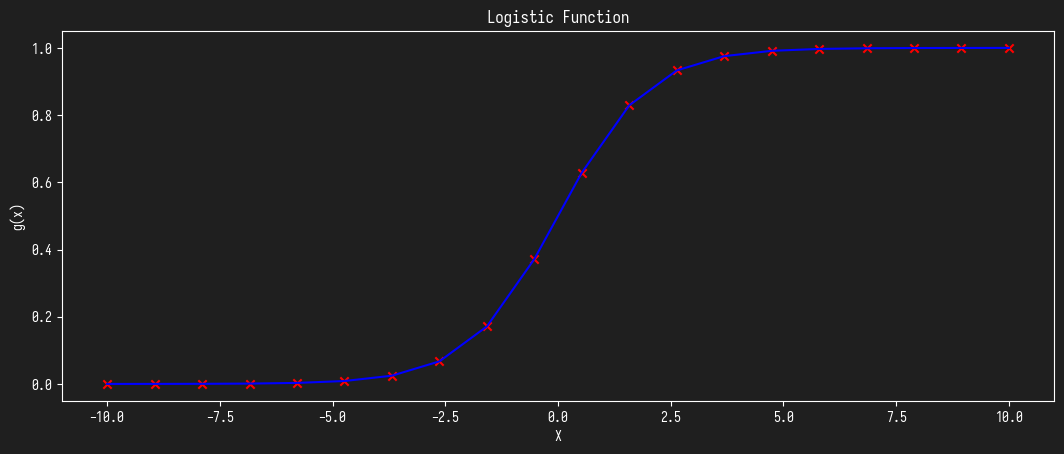

In [2]:
X = numpy.linspace(-10, 10, 20)
G = 1 / (1 + numpy.exp(-X))

matplotlib.pyplot.scatter(X, G, marker="x", c="r")
matplotlib.pyplot.plot(X, G, color="blue", label=f"g(x) = 1 / (1 + e^(-x))")
matplotlib.pyplot.title("Logistic Function")
matplotlib.pyplot.ylabel("g(x)")
matplotlib.pyplot.xlabel("X")
matplotlib.pyplot.show()

### 3.逻辑回归函数

结合一元线性回归公式：

$$ z=\vec{w}\cdot{\vec{x}}+b,f_{\vec{w},b}(\vec{x})=g(z)=\frac{1}{1 + e^{-z}}=>f_{\vec{w},b}(\vec{x})=\frac{1}{1 + e^{-(\vec{w}\cdot{\vec{x}}+b)}} $$

从概率论的角度来说，$f_{\vec{w},b}(\vec{x})$计算的是散列值为1的概率，我们可以记作如下公式：

$$ f_{\vec{w},b}(\vec{x})=P(1|\vec{x};\vec{w},b) $$

同时，根据概率公式，我们也可以得到：

$$ P(1|\vec{x};\vec{w},b) + P(0|\vec{x};\vec{w},b) = 1 $$

### 4.逻辑回归中的决策边界

在逻辑回归中，决策边界（Decision Boundary）是用于划分不同类别的数据点的边界。以下是关于逻辑回归中决策边界的详细解释：

> **决策边界的定义**
> 
> * 在分类问题中，决策边界是一个超平面或超曲面，它将特征空间划分为不同的区域，每个区域对应一个类别。
> * 在逻辑回归中，决策边界是由模型学习到的参数决定的。
> 
> **逻辑回归与决策边界**
> 
> * 逻辑回归通过 sigmoid 函数（或 logistic 函数）将线性组合的特征转换为概率值，该概率值表示样本属于某一类别的可能性。
> * 通常情况下，我们会设定一个阈值（例如 0.5），当概率值大于该阈值时，将样本分类为某一类别；否则，分类为另一类别。
> * 决策边界就是使得概率值等于该阈值的点所构成的集合。
> 
> **线性决策边界**
> 
> * 如果特征之间的关系是线性的，那么逻辑回归产生的决策边界就是一条直线（二维特征空间）或一个超平面（高维特征空间）。
> * 这意味着，可以使用线性方程来描述决策边界。
> 
> **非线性决策边界**
> 
> * 如果特征之间的关系是非线性的，逻辑回归可以通过引入多项式特征或使用其他技术（如核技巧）来学习非线性决策边界。
> * 在这种情况下，决策边界可能是一条曲线或一个复杂的曲面。
> 
> **决策边界的作用**
> 
> * 决策边界能够帮助我们理解逻辑回归模型的分类规则。
> * 通过可视化决策边界，我们可以直观地了解模型如何划分不同类别的数据点。
> 
> **总结**
> 
> * 逻辑回归中的决策边界是模型用于分类数据点的分界线。
> * 它可以是线性的或非线性的，取决于特征之间的关系以及模型所使用的技术。
> * 决策边界的可视化，可以方便人们更直观的理解模型的分类效果。

下方示例为一元线性边界示例，引用决策边界函数：

$$ z=\vec{w}\cdot{\vec{x}}+b=0,w_1=1,w_2=1,b=-8=>x_1+x_2-8=0 $$


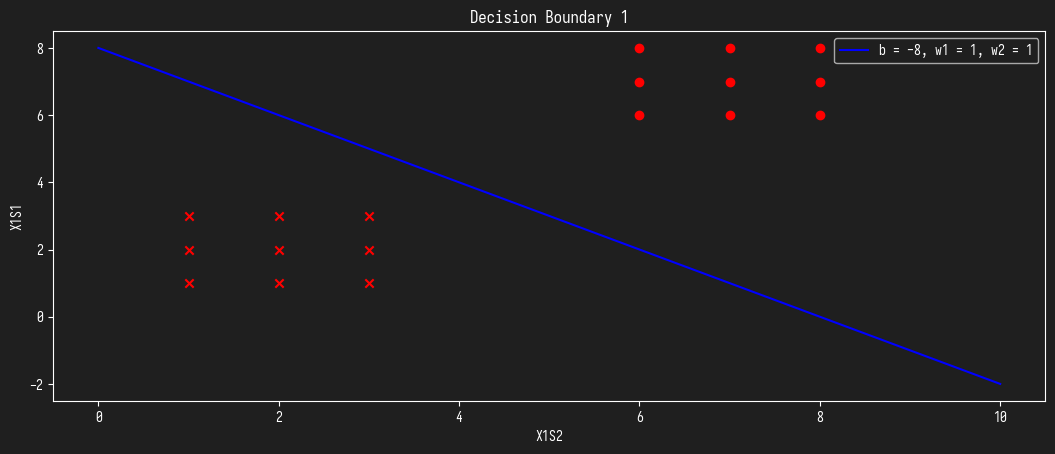

In [3]:
X1S1 = numpy.linspace(0, 10, 40)
X1S2 = numpy.linspace(0, 10, 40)

P1D0 = numpy.array([[1,1],[1,2],[1,3],[2,1],[2,2],[2,3],[3,1],[3,2],[3,3]])
P1D1 = numpy.array([[6,6],[6,7],[6,8],[7,6],[7,7],[7,8],[8,6],[8,7],[8,8]])

matplotlib.pyplot.scatter(P1D0[:,0], P1D0[:,1], marker="x", c="r")
matplotlib.pyplot.scatter(P1D1[:,0], P1D1[:,1], marker="o", c="r")
matplotlib.pyplot.plot(X1S1, 8 - X1S2, color="blue", label=f"b = -8, w1 = 1, w2 = 1")
matplotlib.pyplot.title("Decision Boundary 1")
matplotlib.pyplot.legend()
matplotlib.pyplot.ylabel("X1S1")
matplotlib.pyplot.xlabel("X1S2")
matplotlib.pyplot.show()

下方示例为非线性决策边界，此处引用决策边界函数：

$$ z=\vec{w}\cdot{\vec{x}^2}+b=0,w_1=1,w_2=1,b=-9=>x_1^2+x_2^2-81=0 $$

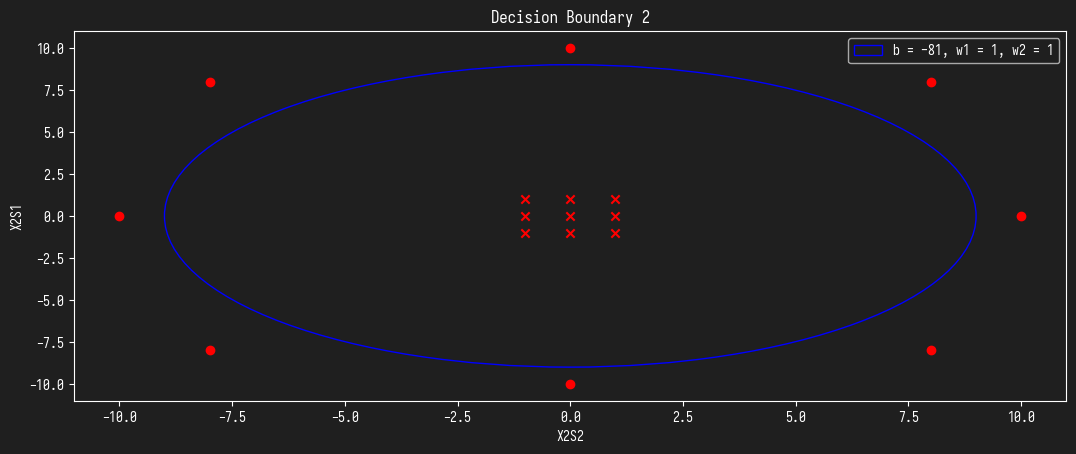

In [4]:
X2S1 = numpy.linspace(-10, 10, 40)
X2S2 = numpy.linspace(-10, 10, 40)

P2D0 = numpy.array([[0,0],[-1,0],[1,0],[0,-1],[-1,-1],[1,-1],[0,1],[-1,1],[1,1]])
P2D1 = numpy.array([[0,10],[0,-10],[10,0],[-10,0],[8,8],[8,-8],[-8,8],[-8,-8]])

matplotlib.pyplot.scatter(P2D0[:,0], P2D0[:,1], marker="x", c="r")
matplotlib.pyplot.scatter(P2D1[:,0], P2D1[:,1], marker="o", c="r")
matplotlib.pyplot.gca().add_patch(matplotlib.patches.Circle((0, 0), 9, color="blue", fill=False, label=f"b = -81, w1 = 1, w2 = 1"))
matplotlib.pyplot.title("Decision Boundary 2")
matplotlib.pyplot.ylabel("X2S1")
matplotlib.pyplot.xlabel("X2S2")
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

### 5.逻辑回归代价函数